In [48]:
ls


 base/                  conv2d.bit                LSI2025-Copy1.ipynb
 common/                conv2d.hwh                LSI2025.ipynb
 conv2d_1_bias.txt      conv2d_weights.txt        output_image.png
 conv2d_1_weights.txt   DATA_DECODER/             pynq_peripherals/
 conv2d_2_bias.txt      flatten_decoder/         'Welcome to Pynq.ipynb'*
 conv2d_2_weights.txt   getting_started/          z_log_var_bias.txt
 conv2d_3_bias.txt      hw_vs_sw_comparison.png   z_log_var_weights.txt
 conv2d_3_weights.txt   input16_14.txt            z_mean_bias.txt
 conv2d_bias.txt        logictools/               z_mean_weights.txt


In [26]:
 from pynq import Overlay
 ol = Overlay("conv2d.bit")

In [27]:
ol.ip_dict

{'top_function_0': {'type': 'xilinx.com:hls:top_function:1.0',
  'mem_id': 's_axi_control',
  'memtype': 'REGISTER',
  'gpio': {},
  'interrupts': {'interrupt': {'controller': 'axi_intc_0',
    'index': 0,
    'fullpath': 'top_function_0/interrupt'}},
  'parameters': {'C_S_AXI_CONTROL_ADDR_WIDTH': '8',
   'C_S_AXI_CONTROL_DATA_WIDTH': '32',
   'C_M_AXI_GMEM_ID_WIDTH': '1',
   'C_M_AXI_GMEM_ADDR_WIDTH': '64',
   'C_M_AXI_GMEM_DATA_WIDTH': '32',
   'C_M_AXI_GMEM_AWUSER_WIDTH': '1',
   'C_M_AXI_GMEM_ARUSER_WIDTH': '1',
   'C_M_AXI_GMEM_WUSER_WIDTH': '1',
   'C_M_AXI_GMEM_RUSER_WIDTH': '1',
   'C_M_AXI_GMEM_BUSER_WIDTH': '1',
   'C_M_AXI_GMEM_USER_VALUE': '0x00000000',
   'C_M_AXI_GMEM_PROT_VALUE': '"000"',
   'C_M_AXI_GMEM_CACHE_VALUE': '"0011"',
   'C_M_AXI_GMEM_ENABLE_ID_PORTS': 'false',
   'C_M_AXI_GMEM_ENABLE_USER_PORTS': 'false',
   'Component_Name': 'conv2d_top_function_0_3',
   'clk_period': '10',
   'machine': '64',
   'combinational': '0',
   'latency': '2455166',
   'II': 'x',
 

In [28]:

 my_ip = ol.top_function_0

In [29]:
my_ip.register_map

RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, RESERVED_3=0, RESERVED_4=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0, CHAN2_INT_EN=0, RESERVED_1=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0, CHAN2_INT_ST=0, RESERVED_1=0),
  input_r_1 = Register(input_r=write-only),
  input_r_2 = Register(input_r=write-only),
  kernel_1_1 = Register(kernel_1=write-only),
  kernel_1_2 = Register(kernel_1=write-only),
  kernel_2_1 = Register(kernel_2=write-only),
  kernel_2_2 = Register(kernel_2=write-only),
  kernel_3_1 = Register(kernel_3=write-only),
  kernel_3_2 = Register(kernel_3=write-only),
  kernel_4_1 = Register(kernel_4=write-only),
  kernel_4_2 = Register(kernel_4=write-only),
  bias_1_1 = Register(bias_1=write-only),
  bias_1_2 = Register(bias_1=write-only),
  bias_2_1 = Register(bias_2=write-only),
  bias_2_2 = Register(bias_2=wri

In [30]:
IMAGE_ROOT  = "DATA_DECODER/smaller"
IMAGE_SIZE = (64, 64)

import os
import glob
import cv2
import numpy as np
# from fxpmath import Fxp
from tqdm import tqdm

# fxp_ref = Fxp(None, dtype='fxp-s16/14')  # Định nghĩa kiểu fixed-point

def get_subset_fixed_point(pathname, name=""):
    images = list()

    for fn in tqdm(glob.glob(pathname), desc=name):
        # Đọc ảnh và xử lý
        image = cv2.imread(fn, flags=cv2.IMREAD_COLOR)
        if image is None:
            print(f"LỖI: Không thể đọc ảnh {fn}")
            continue  # Bỏ qua ảnh lỗi, tránh lỗi `cvtColor`

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, IMAGE_SIZE).astype(np.float32) / 255.0  # Chuẩn hóa về [0, 1]

        # Chuyển đổi sang fixed-point
#         image_fixed_point = Fxp(image, like=fxp_ref)  # <-- Lùi về đúng mức thụt lề
        images.append(image)  # Lưu giá trị fixed-point

    return np.array(images)

# Gọi hàm xử lý ảnh
x_train = get_subset_fixed_point(os.path.join(IMAGE_ROOT, 'train', 'good', '*.png'), 'Train images')
x_good = get_subset_fixed_point(os.path.join(IMAGE_ROOT, 'test', 'good', '*.png'), 'Good')
x_crack = get_subset_fixed_point(os.path.join(IMAGE_ROOT, 'test', 'crack', '*.png'), 'Crack')
x_cut = get_subset_fixed_point(os.path.join(IMAGE_ROOT, 'test', 'cut', '*.png'), 'Cut')
x_hole = get_subset_fixed_point(os.path.join(IMAGE_ROOT, 'test', 'hole', '*.png'), 'Hole')
x_print = get_subset_fixed_point(os.path.join(IMAGE_ROOT, 'test', 'print', '*.png'), 'Print')


Hole:  73%|███████▎  | 8/11 [00:02<00:00,  3.39it/s]

LỖI: Không thể đọc ảnh DATA_DECODER/smaller/test/hole/012.png


Print: 100%|██████████| 10/10 [00:02<00:00,  3.38it/s]


In [31]:
import numpy as np

# Hàm load dữ liệu từ file và chuyển đổi
def load_data(file_path, dtype=np.int16, scale=2**14):
    return (np.loadtxt(file_path) * scale).astype(dtype)

# Nạp input từ file
input_data = load_data('input16_14.txt')

# Nạp trọng số và bias cho các lớp convolution
layer1_weight = load_data('conv2d_weights.txt')
layer1_bias = load_data('conv2d_bias.txt')

layer2_weight = load_data('conv2d_1_weights.txt')
layer2_bias = load_data('conv2d_1_bias.txt')

layer3_weight = load_data('conv2d_2_weights.txt')
layer3_bias = load_data('conv2d_2_bias.txt')

layer4_weight = load_data('conv2d_3_weights.txt')
layer4_bias = load_data('conv2d_3_bias.txt')

# Nạp trọng số và bias cho các lớp Fully Connected (FC)
fc1_weight = load_data('z_mean_weights.txt')
fc1_bias = load_data('z_mean_bias.txt')

fc2_weight = load_data('z_log_var_weights.txt')
fc2_bias = load_data('z_log_var_bias.txt')

# Kiểm tra kích thước dữ liệu đã nạp
print("Input shape:", input_data.shape)
print("Layer 1 weights shape:", layer1_weight.shape, "Bias shape:", layer1_bias.shape)
print("Layer 2 weights shape:", layer2_weight.shape, "Bias shape:", layer2_bias.shape)
print("Layer 3 weights shape:", layer3_weight.shape, "Bias shape:", layer3_bias.shape)
print("Layer 4 weights shape:", layer4_weight.shape, "Bias shape:", layer4_bias.shape)
print("FC1 weights shape:", fc1_weight.shape, "Bias shape:", fc1_bias.shape)
print("FC2 weights shape:", fc2_weight.shape, "Bias shape:", fc2_bias.shape)


Input shape: (12288,)
Layer 1 weights shape: (192,) Bias shape: (16,)
Layer 2 weights shape: (2048,) Bias shape: (32,)
Layer 3 weights shape: (8192,) Bias shape: (64,)
Layer 4 weights shape: (32768,) Bias shape: (128,)
FC1 weights shape: (65536,) Bias shape: (32,)
FC2 weights shape: (65536,) Bias shape: (32,)


In [32]:
print("First 5 values of input_data:", input_data.flatten()[:5])
print("First 5 values of layer1_weight:", layer1_weight.flatten()[:5])


First 5 values of input_data: [2570 2698 2634 2762 2570]
First 5 values of layer1_weight: [ 3254  1187 -1300  4689 -4098]


In [33]:
import numpy as np
from pynq import Overlay, allocate

# 🟢 Tạo buffer đầu vào
input_buffer = allocate(shape=(64*64*3,), dtype=np.int16)

# 🟢 Tạo 2 output buffer
output_buffer1 = allocate(shape=(32,), dtype=np.int16)  # Output buffer 1 (ví dụ: cho FC1)
output_buffer2 = allocate(shape=(32,), dtype=np.int16)  # Output buffer 2 (ví dụ: cho FC2)

# 🟢 Tạo buffer cho các lớp convolution
layer1_weight_buffer = allocate(shape=(2*2*3*16,), dtype=np.int16)
layer1_bias_buffer = allocate(shape=(16,), dtype=np.int16)

layer2_weight_buffer = allocate(shape=(2*2*16*32,), dtype=np.int16)
layer2_bias_buffer = allocate(shape=(32,), dtype=np.int16)

layer3_weight_buffer = allocate(shape=(2*2*32*64,), dtype=np.int16)
layer3_bias_buffer = allocate(shape=(64,), dtype=np.int16)

layer4_weight_buffer = allocate(shape=(2*2*64*128,), dtype=np.int16)
layer4_bias_buffer = allocate(shape=(128,), dtype=np.int16)

# 🟢 Thêm buffer cho Fully Connected (FC)
fc1_weight_buffer = allocate(shape=(2048*32,), dtype=np.int16)  # 2048 input -> 32 output
fc1_bias_buffer = allocate(shape=(32,), dtype=np.int16)  # Bias cho 32 output neurons

fc2_weight_buffer = allocate(shape=(2048*32,), dtype=np.int16)  # 2048 input -> 32 output (FC2 giống FC1)
fc2_bias_buffer = allocate(shape=(32,), dtype=np.int16)  # Bias cho 32 output neurons (FC2)

# 📌 In ra kích thước của buffer
print(f"Input buffer size: {input_buffer.shape}")
print(f"Output buffer 1 size: {output_buffer1.shape}")
print(f"Output buffer 2 size: {output_buffer2.shape}")

print(f"Layer 1 weight buffer size: {layer1_weight_buffer.shape}")
print(f"Layer 1 bias buffer size: {layer1_bias_buffer.shape}")

print(f"Layer 2 weight buffer size: {layer2_weight_buffer.shape}")
print(f"Layer 2 bias buffer size: {layer2_bias_buffer.shape}")

print(f"Layer 3 weight buffer size: {layer3_weight_buffer.shape}")
print(f"Layer 3 bias buffer size: {layer3_bias_buffer.shape}")

print(f"Layer 4 weight buffer size: {layer4_weight_buffer.shape}")
print(f"Layer 4 bias buffer size: {layer4_bias_buffer.shape}")

# ✅ In kích thước buffer của các lớp FC
print(f"FC1 weight buffer size: {fc1_weight_buffer.shape}")
print(f"FC1 bias buffer size: {fc1_bias_buffer.shape}")

print(f"FC2 weight buffer size: {fc2_weight_buffer.shape}")
print(f"FC2 bias buffer size: {fc2_bias_buffer.shape}")


Input buffer size: (12288,)
Output buffer 1 size: (32,)
Output buffer 2 size: (32,)
Layer 1 weight buffer size: (192,)
Layer 1 bias buffer size: (16,)
Layer 2 weight buffer size: (2048,)
Layer 2 bias buffer size: (32,)
Layer 3 weight buffer size: (8192,)
Layer 3 bias buffer size: (64,)
Layer 4 weight buffer size: (32768,)
Layer 4 bias buffer size: (128,)
FC1 weight buffer size: (65536,)
FC1 bias buffer size: (32,)
FC2 weight buffer size: (65536,)
FC2 bias buffer size: (32,)


In [34]:
# Sao chép input vào input_buffer
np.copyto(input_buffer, input_data.flatten())

# Sao chép kernel vào các buffer tương ứng
np.copyto(layer1_weight_buffer, layer1_weight.flatten())  # Lớp 1
np.copyto(layer1_bias_buffer, layer1_bias.flatten())  # Bias lớp 1

np.copyto(layer2_weight_buffer, layer2_weight.flatten())  # Lớp 2
np.copyto(layer2_bias_buffer, layer2_bias.flatten())  # Bias lớp 2

np.copyto(layer3_weight_buffer, layer3_weight.flatten())  # Lớp 3
np.copyto(layer3_bias_buffer, layer3_bias.flatten())  # Bias lớp 3

np.copyto(layer4_weight_buffer, layer4_weight.flatten())  # Lớp 4
np.copyto(layer4_bias_buffer, layer4_bias.flatten())  # Bias lớp 4

# ✅ Sao chép dữ liệu vào buffer của Fully Connected (FC)
np.copyto(fc1_weight_buffer, fc1_weight.flatten())  # FC1 weight
np.copyto(fc1_bias_buffer, fc1_bias.flatten())  # FC1 bias

np.copyto(fc2_weight_buffer, fc2_weight.flatten())  # FC2 weight
np.copyto(fc2_bias_buffer, fc2_bias.flatten())  # FC2 bias


In [35]:
# Ghi địa chỉ vật lý của các buffer vào các thanh ghi tương ứng của IP
my_ip.write(0x10, input_buffer.physical_address)  # Địa chỉ vật lý của input_buffer
my_ip.write(0xac, output_buffer1.physical_address)  # Địa chỉ vật lý của output_buffer
my_ip.write(0xb8, output_buffer2.physical_address)  # Địa chỉ vật lý của output_buffer

# Ghi địa chỉ vật lý của các buffer trọng số và bias cho các lớp CNN
my_ip.write(0x1c, layer1_weight_buffer.physical_address)  # layer1_weight_buffer
my_ip.write(0x4c, layer1_bias_buffer.physical_address)  # layer1_bias_buffer
my_ip.write(0x28, layer2_weight_buffer.physical_address)  # layer2_weight_buffer
my_ip.write(0x58, layer2_bias_buffer.physical_address)  # layer2_bias_buffer
my_ip.write(0x34, layer3_weight_buffer.physical_address)  # layer3_weight_buffer
my_ip.write(0x64, layer3_bias_buffer.physical_address)  # layer3_bias_buffer
my_ip.write(0x40, layer4_weight_buffer.physical_address)  # layer4_weight_buffer
my_ip.write(0x70, layer4_bias_buffer.physical_address)  # layer4_bias_buffer

# Ghi địa chỉ vật lý của buffer trọng số và bias cho hai lớp Fully Connected (FC)
my_ip.write(0x7c, fc1_weight_buffer.physical_address)  # fc1_weight_buffer
my_ip.write(0x94, fc1_bias_buffer.physical_address)  # fc1_bias_buffer
my_ip.write(0x88, fc2_weight_buffer.physical_address)  # fc2_weight_buffer
my_ip.write(0xa0, fc2_bias_buffer.physical_address)  # fc2_bias_buffer


In [36]:
import time

start_time = time.time()

my_ip.write(0x00, 0x01)

while True:
    reg = my_ip.read(0x00)
    if reg != 1:
        break

end_time = time.time()
time_handcoded = end_time - start_time

print("HW time: {}s".format(time_handcoded))


HW time: 0.03201580047607422s


In [37]:
import numpy as np
import time

# Hàm đọc dữ liệu từ file txt (float16)
def load_from_txt(filename):
    return np.loadtxt(filename, dtype=np.float16)

# Đọc dữ liệu từ file
input_image = load_from_txt("input16_14.txt").reshape(64, 64, 3)
weights1 = load_from_txt("conv2d_weights.txt").reshape(2, 2, 3, 16)
bias1 = load_from_txt("conv2d_bias.txt")

weights2 = load_from_txt("conv2d_1_weights.txt").reshape(2, 2, 16, 32)
bias2 = load_from_txt("conv2d_1_bias.txt")

weights3 = load_from_txt("conv2d_2_weights.txt").reshape(2, 2, 32, 64)
bias3 = load_from_txt("conv2d_2_bias.txt")

weights4 = load_from_txt("conv2d_3_weights.txt").reshape(2, 2, 64, 128)
bias4 = load_from_txt("conv2d_3_bias.txt")

weights_fc1 = load_from_txt("z_mean_weights.txt").reshape(-1, 32)
bias_fc1 = load_from_txt("z_mean_bias.txt")

weights_fc2 = load_from_txt("z_log_var_weights.txt").reshape(-1, 32)
bias_fc2 = load_from_txt("z_log_var_bias.txt")

# Hàm Conv2D đơn giản với stride = 2
def conv2d(input_data, weights, bias, stride=2):
    H, W, C_in = input_data.shape
    kH, kW, C_in, C_out = weights.shape
    H_out = (H - kH) // stride + 1
    W_out = (W - kW) // stride + 1
    output = np.zeros((H_out, W_out, C_out), dtype=np.float16)

    for i in range(H_out):
        for j in range(W_out):
            region = input_data[i*stride:i*stride+kH, j*stride:j*stride+kW, :]
            for c in range(C_out):
                output[i, j, c] = np.sum(region * weights[:, :, :, c]) + bias[c]
    
    return np.maximum(output, 0)  # ReLU

# Hàm Fully Connected Layer
def dense(input_data, weights, bias):
    return np.dot(input_data, weights) + bias  # Không dùng ReLU


# Đo thời gian chạy
start_time = time.time()

# Forward qua các layers
x1 = conv2d(input_image, weights1, bias1)
x2 = conv2d(x1, weights2, bias2)
x3 = conv2d(x2, weights3, bias3)
x4 = conv2d(x3, weights4, bias4)

# Flatten
x4 = x4.flatten()

# Fully connected layers
z_mean = dense(x4, weights_fc1, bias_fc1)
z_log_var = dense(x4, weights_fc2, bias_fc2)

end_time = time.time()
sw_time = end_time - start_time

print("SW time: {}s".format(sw_time))


SW time: 5.312296628952026s


In [38]:
# In toàn bộ giá trị của z_mean và z_log_var
print("z_mean:", z_mean)
print("z_log_var:", z_log_var)


z_mean: [ 2.5463e-04 -8.7500e-04 -6.2704e-05  4.9019e-04 -2.7108e-04  4.1127e-04
  5.1451e-04  5.2023e-04 -5.4455e-04 -2.6524e-05 -5.5885e-04 -2.1803e-04
  5.8031e-04  6.1893e-04  5.3740e-04  3.2377e-04 -5.4026e-04 -5.7220e-04
 -2.8706e-04  1.4567e-04 -1.1283e-04 -4.9877e-04  3.0708e-04  1.2255e-04
  9.1314e-04 -3.6287e-04  1.8752e-04 -1.0699e-04 -8.1444e-04  3.4332e-04
 -7.1287e-05  2.0111e-04]
z_log_var: [0.0015335 0.001298  0.001506  0.001548  0.00115   0.001173  0.0017
 0.001233  0.000908  0.001295  0.001133  0.001477  0.001344  0.001498
 0.000927  0.001589  0.001171  0.00153   0.001283  0.001287  0.0009527
 0.001179  0.001081  0.001206  0.000689  0.001454  0.0017605 0.001213
 0.001296  0.001458  0.001615  0.001495 ]


In [39]:
my_ip.register_map.CTRL.AP_DONE

0

In [40]:
output_buffer1

PynqBuffer([  61,   45,   87,  -31,   24,    4,  114,    9,   86,  -11,
             -28, -103,   18,   62,  -31,   73,  -84,  -44,  -20, -104,
             -82,  -50,  -24, -135,  110,   25,  -56,  -65,  -64,   13,
              -4, -113], dtype=int16)

In [41]:
z_mean_hw= (output_buffer1 / 16384.0)
print(z_mean_hw.astype(np.float32))

z_var_hw= (output_buffer2 / 16384.0)
print(z_var_hw.astype(np.float32))


[ 0.00372314  0.00274658  0.00531006 -0.00189209  0.00146484  0.00024414
  0.00695801  0.00054932  0.00524902 -0.00067139 -0.00170898 -0.00628662
  0.00109863  0.00378418 -0.00189209  0.00445557 -0.00512695 -0.00268555
 -0.0012207  -0.00634766 -0.00500488 -0.00305176 -0.00146484 -0.00823975
  0.00671387  0.00152588 -0.00341797 -0.00396729 -0.00390625  0.00079346
 -0.00024414 -0.00689697]
[-0.00067139  0.00628662 -0.00244141  0.00457764  0.00592041 -0.00170898
  0.0012207   0.00109863  0.00488281  0.00427246  0.0012207   0.00909424
  0.00665283 -0.00610352 -0.00946045  0.00073242  0.00262451  0.00048828
  0.00457764  0.00787354  0.00378418  0.00598145  0.00622559  0.00964355
 -0.00537109  0.00390625 -0.01074219 -0.00305176 -0.00366211 -0.00067139
 -0.0010376  -0.00073242]


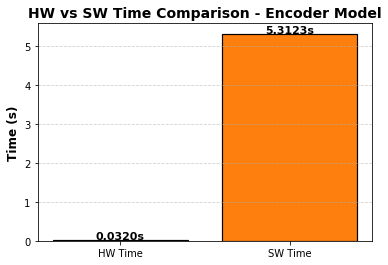

In [42]:
import matplotlib.pyplot as plt

# Labels and values
labels = ['HW Time', 'SW Time']
times = [time_handcoded, sw_time]

# Create figure and set background color to white
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# Draw bar chart
bars = ax.bar(labels, times, color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.2)

# Add labels and title
ax.set_ylabel('Time (s)', fontsize=12, fontweight='bold', color='black')
ax.set_title('HW vs SW Time Comparison - Encoder Model', fontsize=14, fontweight='bold', color='black')

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.4f}s", 
            ha='center', fontsize=11, fontweight='bold', color='black')

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Remove frame background
ax.set_facecolor('white')

# Save image with white background
plt.savefig("hw_vs_sw_comparison.png", dpi=300, bbox_inches='tight', transparent=False)

# Show the chart
plt.show()


In [43]:
output_buffer2

PynqBuffer([ -11,  103,  -40,   75,   97,  -28,   20,   18,   80,   70,
              20,  149,  109, -100, -155,   12,   43,    8,   75,  129,
              62,   98,  102,  158,  -88,   64, -176,  -50,  -60,  -11,
             -17,  -12], dtype=int16)

In [44]:
print("🔹 z_mean_hw shape:", z_mean_hw.shape)
print("🔹 z_var_hw shape:", z_var_hw.shape)


🔹 z_mean_hw shape: (32,)
🔹 z_var_hw shape: (32,)


In [45]:
import numpy as np
# Chia và ép kiểu dữ liệu
z_mean_hw = (output_buffer1 / 16384.0).astype(np.float32)
print("🔹 z_mean_hw:", z_mean_hw)

z_var_hw = (output_buffer2 / 16384.0).astype(np.float32)
print("🔹 z_var_hw:", z_var_hw)

# ======= Hàm ReLU =======
def relu(x):
    return np.maximum(0, x)

class DenseLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.weights = None
        self.bias = None

    def load_weights(self, weight_file, bias_file):
        """Load weights và bias từ file .npy"""
        self.weights = np.load(weight_file)  # Load weights từ .npy
        self.bias = np.load(bias_file).reshape((self.output_dim,))  # Đảm bảo bias có shape đúng

        # Kiểm tra kích thước để tránh lỗi khi tính toán
        assert self.weights.shape == (self.output_dim, self.input_dim), f"Lỗi kích thước weights: {self.weights.shape} != ({self.output_dim}, {self.input_dim})"
        assert self.bias.shape == (self.output_dim,), f"Lỗi kích thước bias: {self.bias.shape} != ({self.output_dim},)"

    def call(self, input_data):
        """Tính toán đầu ra của Dense Layer"""
        if self.weights is None or self.bias is None:
            raise ValueError("Chưa load weights và bias!")
        output = np.dot(input_data, self.weights.T) + self.bias
        return relu(output)

# ======= Hàm Reparameterization Trick =======
def reparameterize(z_mean, z_log_var):
    """Tạo mẫu z từ z_mean và z_log_var theo reparam trick."""
    epsilon = np.random.normal(size=z_mean.shape)  # Mẫu ngẫu nhiên từ phân phối chuẩn
    return z_mean + np.exp(0.5 * z_log_var) * epsilon  # Công thức reparameterization

# ======= Tạo z từ Reparameterization Trick =======
latent_dim = 32
z_mean_hw = (output_buffer1 / 16384.0).astype(np.float32)
print("🔹 z_mean_hw:", z_mean_hw)

z_var_hw = (output_buffer2 / 16384.0).astype(np.float32)
print("🔹 z_var_hw:", z_var_hw)


z = reparameterize(z_mean_hw, z_var_hw)  # ✅ Tạo z có shape (1, 32)

# ======= Dense Layer 32 -> 4x4x128 =======
dense_layer = DenseLayer(latent_dim, 4 * 4 * 128)
dense_layer.load_weights("DATA_DECODER/dense_1_weights.npy",
                         "DATA_DECODER/dense_1_bias.npy")  # Load từ .npy

dense_output = dense_layer.call(z).reshape((4, 4, 128))  # Reshape thành (4, 4, 128)
dense_output = np.transpose(dense_output, (2, 0, 1))  # Chuyển thành (128, 4, 4)

print("✅ Dense Layer Output Shape:", dense_output.shape)  # Kết quả mong muốn: (128, 4, 4)

print(dense_output)


🔹 z_mean_hw: [ 0.00372314  0.00274658  0.00531006 -0.00189209  0.00146484  0.00024414
  0.00695801  0.00054932  0.00524902 -0.00067139 -0.00170898 -0.00628662
  0.00109863  0.00378418 -0.00189209  0.00445557 -0.00512695 -0.00268555
 -0.0012207  -0.00634766 -0.00500488 -0.00305176 -0.00146484 -0.00823975
  0.00671387  0.00152588 -0.00341797 -0.00396729 -0.00390625  0.00079346
 -0.00024414 -0.00689697]
🔹 z_var_hw: [-0.00067139  0.00628662 -0.00244141  0.00457764  0.00592041 -0.00170898
  0.0012207   0.00109863  0.00488281  0.00427246  0.0012207   0.00909424
  0.00665283 -0.00610352 -0.00946045  0.00073242  0.00262451  0.00048828
  0.00457764  0.00787354  0.00378418  0.00598145  0.00622559  0.00964355
 -0.00537109  0.00390625 -0.01074219 -0.00305176 -0.00366211 -0.00067139
 -0.0010376  -0.00073242]
🔹 z_mean_hw: [ 0.00372314  0.00274658  0.00531006 -0.00189209  0.00146484  0.00024414
  0.00695801  0.00054932  0.00524902 -0.00067139 -0.00170898 -0.00628662
  0.00109863  0.00378418 -0.001892

In [46]:

class Conv2DTranspose:
    def __init__(self, kernel, bias, stride=2, activation="relu"):
        self.kernel = kernel
        self.bias = bias
        self.stride = stride
        self.activation = activation

    def forward(self, x):
        input_channels, input_h, input_w = x.shape
        num_filters, _, kernel_size, _ = self.kernel.shape
        output_h, output_w = input_h * self.stride, input_w * self.stride

        # Khởi tạo output
        output = np.zeros((num_filters, output_h, output_w), dtype=np.float32)

        # Thực hiện phép toán Conv2D Transpose
        for f in range(num_filters):
            for h in range(input_h):
                for w in range(input_w):
                    for c_in in range(input_channels):
                        input_val = x[c_in, h, w]
                        for kh in range(kernel_size):
                            for kw in range(kernel_size):
                                out_h = h * self.stride + kh
                                out_w = w * self.stride + kw
                                if out_h < output_h and out_w < output_w:
                                    output[f, out_h, out_w] += input_val * self.kernel[f, c_in, kh, kw]

            # Thêm bias và activation
            output[f] += self.bias[f]
            output[f] = self.activate(output[f])

        return output

    def activate(self, x):
        if self.activation == "relu":
            return np.maximum(0, x)
        elif self.activation == "sigmoid":
            return 1 / (1 + np.exp(-x))
        return x  # Không có activation

import numpy as np


# Đọc trọng số và bias từ các file .npy
weights_transposed_4 = np.load('DATA_DECODER/conv2d_transpose_4_weights.npy')
biases_conv2d_4 = np.load('DATA_DECODER/conv2d_transpose_4_bias.npy')

weights_transposed_4 = np.transpose(weights_transposed_4, (1,0, 2, 3))  # (height, input_channels, width)


weights_transposed_5 = np.load('DATA_DECODER/conv2d_transpose_5_weights.npy')


weights_transposed_5 = np.transpose(weights_transposed_5, (1,0, 2, 3))  # (height, input_channels, width)
biases_conv2d_5 = np.load('DATA_DECODER/conv2d_transpose_5_bias.npy')

weights_transposed_6 = np.load('DATA_DECODER/conv2d_transpose_6_weights.npy')


weights_transposed_6 = np.transpose(weights_transposed_6, (1,0, 2, 3))  # (height, input_channels, width)
biases_conv2d_6 = np.load('DATA_DECODER/conv2d_transpose_6_bias.npy')

weights_transposed_7 = np.load('DATA_DECODER/conv2d_transpose_7_weights.npy')


weights_transposed_7 = np.transpose(weights_transposed_7, (1,0, 2, 3))  # (height, input_channels, width)
biases_conv2d_7 = np.load('DATA_DECODER/conv2d_transpose_7_bias.npy')


# Kiểm tra kích thước của trọng số và bias đã tải
print("Shape of weights_transposed_4:", weights_transposed_4.shape)
print("Shape of biases_conv2d_4:", biases_conv2d_4.shape)

print("Shape of weights_transposed_5:", weights_transposed_5.shape)
print("Shape of biases_conv2d_5:", biases_conv2d_5.shape)

print("Shape of weights_transposed_6:", weights_transposed_6.shape)
print("Shape of biases_conv2d_6:", biases_conv2d_6.shape)

print("Shape of weights_transposed_7:", weights_transposed_7.shape)
print("Shape of biases_conv2d_7:", biases_conv2d_7.shape)


# # Kiểm tra kích thước sau khi chuyển vị
# print("Shape after transpose:", input_data_transposed.shape)

# Tạo lớp Conv2DTranspose thứ 4 và chạy forward pass
layer_1 = Conv2DTranspose(weights_transposed_4, biases_conv2d_4, stride=2, activation="relu")
output_1 = layer_1.forward(dense_output)
print("Output after Conv2DTranspose layer 4:", output_1.shape)

# Tạo lớp Conv2DTranspose thứ 5 và chạy forward pass
layer_2 = Conv2DTranspose(weights_transposed_5, biases_conv2d_5, stride=2, activation="relu")
output_2 = layer_2.forward(output_1)
print("Output after Conv2DTranspose layer 5:", output_2.shape)

# Tạo lớp Conv2DTranspose thứ 6 và chạy forward pass
layer_3 = Conv2DTranspose(weights_transposed_6, biases_conv2d_6, stride=2, activation="relu")
output_3 = layer_3.forward(output_2)
print("Output after Conv2DTranspose layer 6:", output_3.shape)

# Tạo lớp Conv2DTranspose thứ 7 và chạy forward pass
layer_4 = Conv2DTranspose(weights_transposed_7, biases_conv2d_7, stride=2, activation="sigmoid")
output_4 = layer_4.forward(output_3)
print("Output after Conv2DTranspose layer 7:", output_4.shape)

# In output cuối cùng
print(output_4)




Shape of weights_transposed_4: (64, 128, 2, 2)
Shape of biases_conv2d_4: (64,)
Shape of weights_transposed_5: (32, 64, 2, 2)
Shape of biases_conv2d_5: (32,)
Shape of weights_transposed_6: (16, 32, 2, 2)
Shape of biases_conv2d_6: (16,)
Shape of weights_transposed_7: (3, 16, 2, 2)
Shape of biases_conv2d_7: (3,)
Output after Conv2DTranspose layer 4: (64, 8, 8)
Output after Conv2DTranspose layer 5: (32, 16, 16)
Output after Conv2DTranspose layer 6: (16, 32, 32)
Output after Conv2DTranspose layer 7: (3, 64, 64)
[[[0.15980212 0.16283046 0.1581363  ... 0.15899089 0.15382993 0.15355507]
  [0.16373304 0.15923744 0.1584648  ... 0.15289362 0.14998727 0.15397353]
  [0.16392086 0.1613628  0.16357392 ... 0.1526611  0.15442942 0.15586156]
  ...
  [0.1692427  0.16350214 0.16066144 ... 0.15380976 0.15982135 0.1617853 ]
  [0.1690564  0.1661518  0.16582249 ... 0.15802097 0.16222398 0.16428585]
  [0.16696168 0.1654866  0.16659492 ... 0.1531901  0.16130027 0.15883656]]

 [[0.158873   0.15620326 0.16036868 

Number of filters (channels): 3
Height: 64
Width: 64
PASS
Data type: uint8, Shape: (64, 64, 3)
Pixel range: 30 - 147


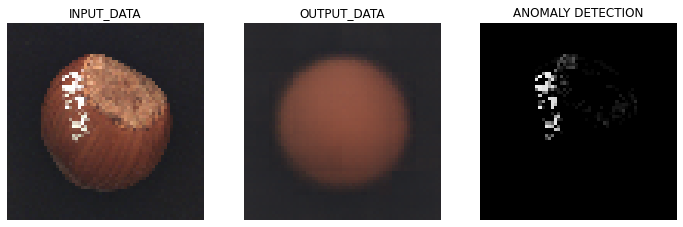

In [47]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# Giả sử output_4 là đầu ra của một lớp Conv2DTranspose có kích thước (num_filters, height, width)
num_filters, height, width = output_4.shape
print("Number of filters (channels):", num_filters)
print("Height:", height)
print("Width:", width)

# Đảm bảo có đủ ít nhất 3 kênh, nếu không, sao chép kênh để tạo ảnh RGB
if num_filters >= 3:
    rgb_image = output_4[:3]  # Chọn ba kênh đầu tiên
    print("PASS")
else:
    rgb_image = np.zeros((3, height, width), dtype=np.float32)
    for i in range(num_filters):
        rgb_image[i] = output_4[i]
    for i in range(num_filters, 3):
        rgb_image[i] = output_4[0]  # Sao chép kênh đầu tiên để làm đầy ảnh RGB

# Chuẩn hóa pixel về [0,1]
rgb_image = np.clip(rgb_image, 0, 1)  
rgb_image = (rgb_image * 255).astype(np.uint8)  # Chuyển về 0-255

# Chuyển đổi từ (channels, height, width) sang (height, width, channels)
rgb_image = rgb_image.transpose(1, 2, 0)

# Kiểm tra dữ liệu
print(f"Data type: {rgb_image.dtype}, Shape: {rgb_image.shape}")
print(f"Pixel range: {rgb_image.min()} - {rgb_image.max()}")

# Lưu ảnh
image_recon = Image.fromarray(rgb_image)
image_recon.save("output_image.png")

# Hiển thị ảnh gốc và ảnh tái tạo
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("INPUT_DATA")
plt.imshow(x_print[0])  # Ảnh gốc
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("OUTPUT_DATA")
plt.imshow(rgb_image)  # Ảnh tái tạo từ mạng
plt.axis("off")

# Chia lại ảnh recon cho 255 trước khi so sánh
rgb_image = rgb_image.astype(np.float32) / 255.0

# Đọc ảnh gốc
image = x_print[0]

# Tính toán bản đồ lỗi
error_image = (image - rgb_image) ** 2

# Ngưỡng lỗi
threshold = 0.04
error_image[error_image < threshold] = 0

# Làm đậm lỗi
factor = 1
error_image_enhanced = np.where(error_image > 0, np.clip(error_image * factor, 0, 1), error_image)

# Nếu ảnh có nhiều kênh (RGB), tính toán lỗi trung bình
if error_image.ndim == 3:
    error_image_enhanced = np.mean(error_image_enhanced, axis=-1)

plt.subplot(1, 3, 3)
plt.title("ANOMALY DETECTION")
plt.imshow(error_image_enhanced, cmap="gray")  # Dùng cmap để làm nổi bật lỗi
plt.axis("off")

plt.show()


In [2]:
import fxpmath